# ====================== SETUP ======================

In [36]:
import PIL
print("Pillow version:", PIL.__version__)

from facenet_pytorch import MTCNN
print("facenet-pytorch loaded OK")

Pillow version: 10.2.0
facenet-pytorch loaded OK


In [37]:
!pip install -q facenet-pytorch albumentations gdown seaborn opencv-python
!pip install Pillow==10.2.0 --force-reinstall

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import cv2
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
plt.style.use('seaborn-v0_8')

  Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
✅ Using device: cpu


# ====================== DOWNLOAD MSCTD ======================

In [38]:
!mkdir -p /content/drive/MyDrive/datasets_s/enzh_1/{train,dev,test}

print("Downloading labels...")
base = "https://github.com/XL2248/MSCTD/raw/main/MSCTD_data/enzh"
!wget -q {base}/sentiment_train.txt -O /content/drive/MyDrive/datasets_s/enzh_1/sentiment_train.txt
!wget -q {base}/sentiment_dev.txt   -O /content/drive/MyDrive/datasets_s/enzh_1/sentiment_dev.txt
!wget -q {base}/sentiment_test.txt  -O /content/drive/MyDrive/datasets_s/enzh_1/sentiment_test.txt
!wget -q {base}/img_index_train.txt -O /content/drive/MyDrive/datasets_s/enzh_1/img_index_train.txt

print("Downloading images (Dev & Test)...")
!gdown --id 12HM8uVNjFg-HRZ15ADue4oLGFAYQwvTA -O /content/drive/MyDrive/datasets_s/enzh_1/dev_images.zip
!gdown --id 1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W -O /content/drive/MyDrive/datasets_s/enzh_1/test_images.zip

print("Unzipping...")
!unzip -o -q /content/drive/MyDrive/datasets_s/enzh_1/dev_images.zip  -d /content/drive/MyDrive/datasets_s/enzh_1/dev/
!unzip -o -q /content/drive/MyDrive/datasets_s/enzh_1/test_images.zip -d /content/drive/MyDrive/datasets_s/enzh_1/test/
print("Unzipping done!")

print("✅ Download completed!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=12HM8uVNjFg-HRZ15ADue4oLGFAYQwvTA
From (redirected): https://drive.google.com/uc?id=12HM8uVNjFg-HRZ15ADue4oLGFAYQwvTA&confirm=t&uuid=288884a4-5f42-40fb-90ce-ac079e5175b5
To: /content/drive/MyDrive/datasets_s/enzh_1/dev_images.zip
100% 638M/638M [00:09<00:00, 70.1MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W
From (redirected): https://drive.google.com/uc?id=1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W&confirm=t&uuid=b183a189-ee7b-41b1-b62c-166124

#Cell 3: Dataset Class + Visualization Functions

In [39]:
class MSCTDDataset(Dataset):
    def __init__(self, image_dir, sentiment_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        with open(sentiment_path, 'r') as f:
            self.labels = [int(x.strip()) for x in f.readlines()]

        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')],
                                  key=lambda x: int(x.split('.')[0]))
        self.length = min(len(self.labels), len(self.image_files))

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        try:
            img = Image.open(img_path).convert('RGB')
        except Image.UnidentifiedImageError:
            # Fallback to OpenCV if PIL fails to identify image
            print(f"Warning: PIL could not process image {img_path}. Attempting with OpenCV.")
            img_cv = cv2.imread(img_path)
            if img_cv is not None:
                img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
                img = Image.fromarray(img_cv)
            else:
                raise FileNotFoundError(f"Could not load image with PIL or OpenCV: {img_path}")

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ====================== VISUALIZATION ======================
def plot_class_distribution(labels, title="Sentiment Distribution"):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=labels, palette='viridis')
    plt.title(title)
    plt.xlabel("Sentiment (0=Neutral, 1=Negative, 2=Positive)")
    plt.ylabel("Count")
    plt.show()

def show_random_samples(dataset, num=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    for i in range(num):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx] if not isinstance(dataset[idx][0], torch.Tensor) else (dataset[idx][0], dataset[idx][1])
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
            img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
            img = np.clip(img, 0, 1)

        sentiment_map = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {sentiment_map[label.item()]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral','Negative','Positive'],
                yticklabels=['Neutral','Negative','Positive'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

#Cell 4: Models

In [40]:
class FaceSentimentModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = models.resnet18(weights='IMAGENET1K_V1')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

class FullImageModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

class FusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(10, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, face_probs, full_probs, num_faces_onehot):
        x = torch.cat([face_probs, full_probs, num_faces_onehot], dim=1)
        return self.fc(x)

#Cell 5: Transforms + Training Function

In [41]:
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def train_model(model, train_loader, epochs=5, name="model"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}")

    # Plot loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(losses, marker='o')
    plt.title(f'{name} Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

    torch.save(model.state_dict(), f"/content/{name}_final.pth")
    return model

#Cell 6: Main Execution + Visualizations

Visualizing dataset...


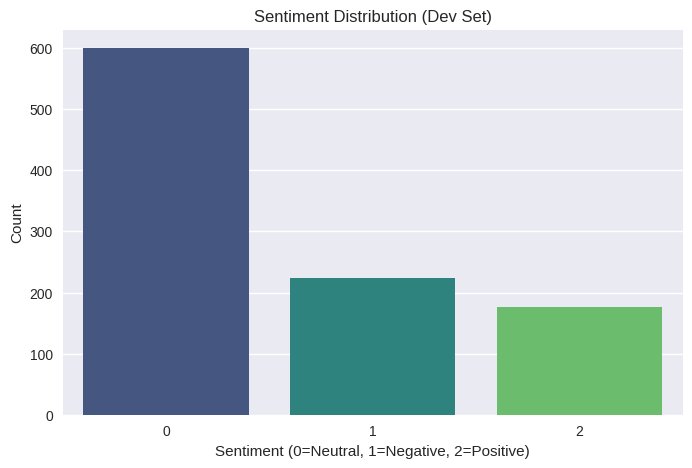

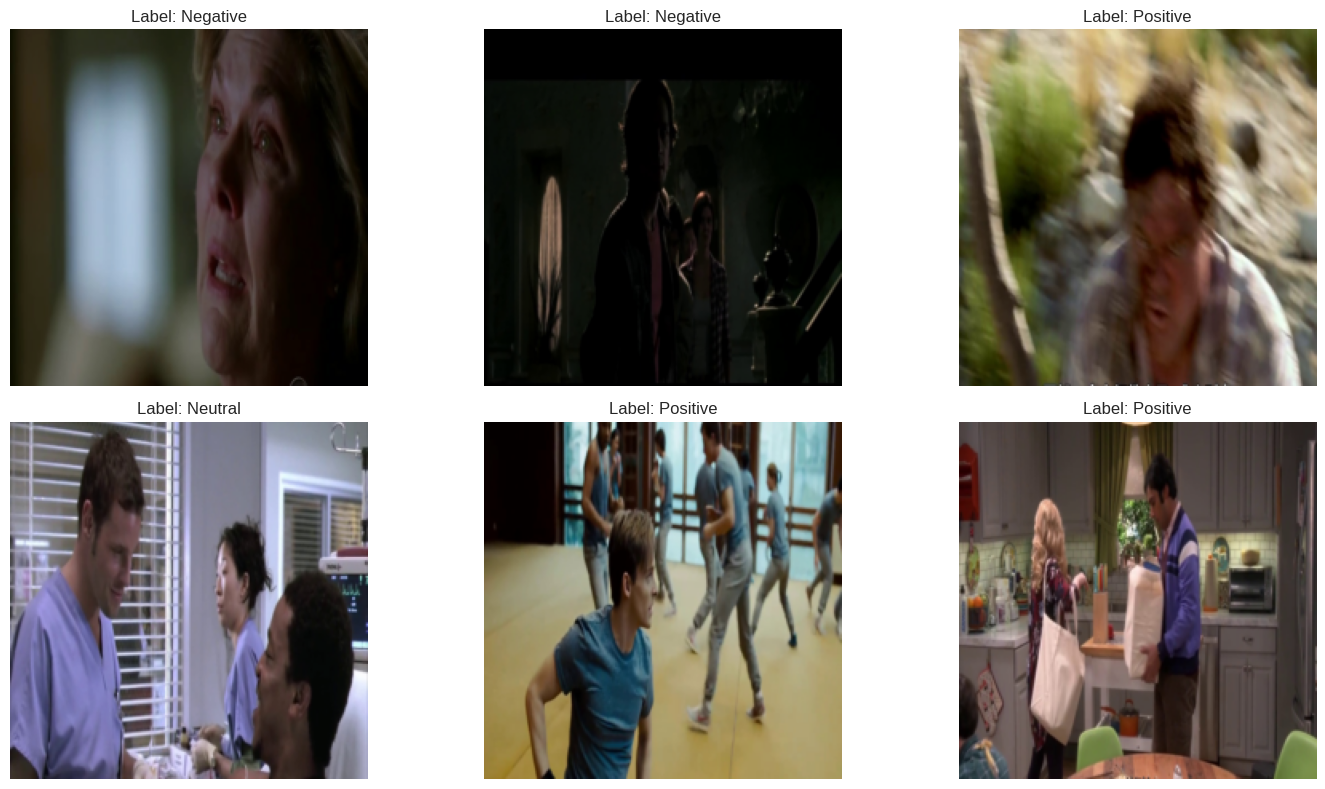


🎉 Setup complete with visualizations!
Next: Add Face Extraction + Fusion Training


In [42]:
# ====================== MAIN EXECUTION ======================

train_image_dir = "/content/drive/MyDrive/datasets_s/enzh_1/train"   # ← Update after adding train images
dev_image_dir   = "/content/drive/MyDrive/datasets_s/enzh_1/dev/dev" # Corrected path to images
dev_sentiment   = "/content/drive/MyDrive/datasets_s/enzh_1/sentiment_dev.txt"

# Load dev set for visualization (smaller and ready)
dev_ds = MSCTDDataset(dev_image_dir, dev_sentiment, test_transform)

print("Visualizing dataset...")
labels = [dev_ds[i][1].item() for i in range(min(1000, len(dev_ds)))]
plot_class_distribution(labels, "Sentiment Distribution (Dev Set)")
show_random_samples(dev_ds, num=6)

# Train example (Full Image Model)
full_model = FullImageModel()
# full_model = train_model(full_model, train_loader, epochs=3, name="full_image")  # Uncomment when train data ready

print("\n🎉 Setup complete with visualizations!")
print("Next: Add Face Extraction + Fusion Training")

In [43]:
image_path = '/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/0.jpg'

if os.path.exists(image_path):
    print(f"File exists: {image_path}")
    print(f"File size: {os.path.getsize(image_path)} bytes")
    try:
        with Image.open(image_path) as img:
            print(f"Image format detected by PIL: {img.format}")
            img.verify()
            print("Image integrity verified by PIL.")
    except Exception as e:
        print(f"PIL could not process image: {e}")

    # Try using 'file' command to get file type (if available)
    print("Attempting to get file type using shell command:")
    !file "{image_path}"
else:
    print(f"File does not exist: {image_path}")

File exists: /content/drive/MyDrive/datasets_s/enzh_1/dev/dev/0.jpg
File size: 67722 bytes
Image format detected by PIL: JPEG
Image integrity verified by PIL.
Attempting to get file type using shell command:
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/0.jpg: JPEG image data, JFIF standard 1.01, aspect ratio, density 1x1, segment length 16, baseline, precision 8, 1024x495, components 3


Generating predictions for visualization...


Predicting on Dev Set: 100%|██████████| 159/159 [20:01<00:00,  7.56s/it]

Plotting confusion matrix...


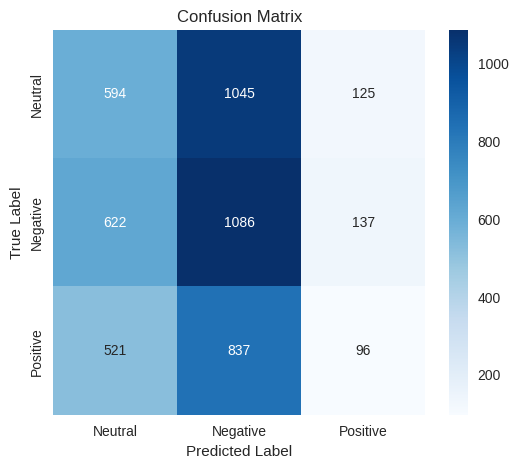

Visualizations complete!


In [44]:
from sklearn.metrics import confusion_matrix

# Assuming full_model and dev_ds are available from previous cells
# (full_model is currently untrained, so results will be random)

dev_loader = DataLoader(dev_ds, batch_size=32, shuffle=False)

# Evaluate the model on the dev set to get predictions
full_model.eval()
full_model.to(device)

y_true = []
y_pred = []

print("Generating predictions for visualization...")
with torch.no_grad():
    for images, labels in tqdm(dev_loader, desc="Predicting on Dev Set"):
        images = images.to(device)
        outputs = full_model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Plot Confusion Matrix
print("Plotting confusion matrix...")
plot_confusion_matrix(y_true, y_pred)
print("Visualizations complete!")

In [45]:
from sklearn.metrics import classification_report

# Assuming y_true and y_pred are available from previous cells

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Neutral', 'Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

     Neutral       0.34      0.34      0.34      1764
    Negative       0.37      0.59      0.45      1845
    Positive       0.27      0.07      0.11      1454

    accuracy                           0.35      5063
   macro avg       0.33      0.33      0.30      5063
weighted avg       0.33      0.35      0.31      5063



In [46]:
import torch.nn.functional as F
from facenet_pytorch import MTCNN
from torchvision import transforms
from PIL import Image
import cv2 # For fallback image loading

# ====================== FACE EXTRACTION ======================
class FaceExtractor:
    def __init__(self, device):
        # MTCNN for face detection
        self.mtcnn = MTCNN(keep_all=True, selection_method='center_weighted_size', device=device)

    def extract_faces(self, image_pil):
        # image_pil should be a PIL Image
        boxes, _ = self.mtcnn.detect(image_pil)

        cropped_faces_pil = []
        if boxes is not None:
            for box in boxes:
                # Ensure box coordinates are integers
                x1, y1, x2, y2 = [int(b) for b in box]
                # Crop face, ensuring coordinates are within image bounds
                width, height = image_pil.size
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(width, x2)
                y2 = min(height, y2)

                if x2 > x1 and y2 > y1: # Ensure valid crop
                    face = image_pil.crop((x1, y1, x2, y2))
                    cropped_faces_pil.append(face)
        return cropped_faces_pil, len(cropped_faces_pil)


# ====================== DATASET FOR FUSION MODEL ======================
class MSCTDFaceDataset(MSCTDDataset):
    def __init__(self, image_dir, sentiment_path, face_extractor, full_image_transform=None, face_transform=None, max_faces_onehot=5):
        super().__init__(image_dir, sentiment_path, full_image_transform)
        self.face_extractor = face_extractor
        self.face_transform = face_transform if face_transform else transforms.ToTensor() # Default face transform
        self.max_faces_onehot = max_faces_onehot # Max faces for one-hot encoding

    def __getitem__(self, idx):
        # Re-read image as PIL Image specifically for face extraction
        img_path = os.path.join(self.image_dir, self.image_files[idx])

        try:
            original_img_pil = Image.open(img_path).convert('RGB')
        except Image.UnidentifiedImageError:
            # Fallback to OpenCV if PIL fails to identify image
            print(f"Warning: PIL could not process image {img_path}. Attempting with OpenCV.")
            img_cv = cv2.imread(img_path)
            if img_cv is not None:
                img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
                original_img_pil = Image.fromarray(img_cv)
            else:
                raise FileNotFoundError(f"Could not load image with PIL or OpenCV: {img_path}")


        # Extract faces (returns a list of PIL images)
        cropped_faces_pil, num_faces_detected = self.face_extractor.extract_faces(original_img_pil)

        # Apply transform to full image
        full_image_tensor = self.transform(original_img_pil) if self.transform else transforms.ToTensor()(original_img_pil)

        # Apply transform to each face
        face_tensors = [self.face_transform(face) for face in cropped_faces_pil]

        # Prepare one-hot encoding for number of faces
        num_faces_onehot = torch.zeros(self.max_faces_onehot + 1)
        if num_faces_detected <= self.max_faces_onehot:
            num_faces_onehot[num_faces_detected] = 1
        else:
            num_faces_onehot[self.max_faces_onehot] = 1 # Cap at max_faces_onehot

        label = self.labels[idx]

        return full_image_tensor, face_tensors, num_faces_onehot, torch.tensor(label, dtype=torch.long)

# ====================== COLLATE FUNCTION FOR FUSION MODEL ======================
def collate_fn_faces(batch):
    # Separate the data from the batch
    full_images = [item[0] for item in batch]
    list_of_face_tensors = [item[1] for item in batch] # This is a list of lists of face tensors
    num_faces_onehot = [item[2] for item in batch]
    labels = [item[3] for item in batch]

    # Stack full images, labels, and num_faces_onehot into single tensors
    full_images_batch = torch.stack(full_images)
    labels_batch = torch.stack(labels)
    num_faces_onehot_batch = torch.stack(num_faces_onehot)

    # Flatten the list of lists of face tensors for batching, keeping track of original batch structure
    all_faces_flat = []
    face_counts = [] # Stores how many faces belong to each original image in the batch
    for faces_in_single_image in list_of_face_tensors:
        all_faces_flat.extend(faces_in_single_image)
        face_counts.append(len(faces_in_single_image))

    # Stack all faces into a single batch. If no faces, create an empty tensor of appropriate shape.
    if all_faces_flat:
        all_faces_batch = torch.stack(all_faces_flat)
    else:
        # Determine the expected shape from a dummy tensor or first full_image if possible
        # Assuming face images have 3 channels and a fixed size (e.g., 224x224 after transform)
        # If full_images_batch is not empty, use its channel/height/width as a guide for face image shape too
        if full_images_batch.shape[0] > 0: # Check if full_images_batch has data
            # This assumes face_transform resizes to 224x224 similar to full_image_transform
            all_faces_batch = torch.empty(0, full_images_batch.shape[1], full_images_batch.shape[2], full_images_batch.shape[3])
        else:
            # Default if no full images either, e.g., for an entirely empty batch (unlikely for real data)
            all_faces_batch = torch.empty(0, 3, 224, 224) # Placeholder shape

    return full_images_batch, all_faces_batch, face_counts, num_faces_onehot_batch, labels_batch

# ====================== TRAINING FUNCTION FOR FUSION MODEL ======================
def train_fusion_model(full_model, face_model, fusion_model, train_loader, epochs=5, name="fusion_model"):
    # Set full_model and face_model to evaluation mode and move to device
    full_model.eval()
    face_model.eval()

    full_model.to(device)
    face_model.to(device)
    fusion_model.to(device)

    optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(epochs):
        fusion_model.train()
        epoch_loss = 0
        for full_images_batch, all_faces_batch, face_counts, num_faces_onehot_batch, labels_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            full_images_batch = full_images_batch.to(device)
            num_faces_onehot_batch = num_faces_onehot_batch.to(device)
            labels_batch = labels_batch.to(device)

            # 1. Get full_probs from FullImageModel (no_grad as it's pre-trained/fixed)
            with torch.no_grad():
                full_probs = F.softmax(full_model(full_images_batch), dim=1)

            # 2. Get face_probs from FaceSentimentModel (no_grad as it's pre-trained/fixed)
            face_probs_list = []
            current_face_idx = 0
            with torch.no_grad():
                for count in face_counts:
                    if count > 0:
                        # Get faces belonging to the current original image
                        faces_for_current_image = all_faces_batch[current_face_idx : current_face_idx + count].to(device)
                        face_output = face_model(faces_for_current_image)

                        # Aggregate face probabilities for the current image (mean aggregation)
                        aggregated_face_prob = F.softmax(face_output, dim=1).mean(dim=0)
                        face_probs_list.append(aggregated_face_prob)
                    else:
                        # If no faces detected for an image, provide a neutral/zero probability vector
                        face_probs_list.append(torch.zeros(3, device=device)) # Assuming 3 classes
                    current_face_idx += count

            # Stack aggregated face probabilities for the batch
            if face_probs_list:
                face_probs_batch = torch.stack(face_probs_list)
            else:
                # This case should ideally be handled by ensuring face_probs_list is always populated
                # with a zero tensor if no faces, or by not having empty batches.
                # For robustness, providing an empty tensor with correct dimensions if somehow still empty.
                face_probs_batch = torch.empty(len(labels_batch), 3, device=device) # Adjust if batch can be entirely empty of faces

            # 3. Pass to FusionModel for training
            optimizer.zero_grad()
            outputs = fusion_model(face_probs_batch, full_probs, num_faces_onehot_batch)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}")

    # Plot loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(losses, marker='o')
    plt.title(f'{name} Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

    torch.save(fusion_model.state_dict(), f"/content/{name}_final.pth")
    return fusion_model

Generating probability scores for ROC AUC...


Predicting probabilities on Dev Set: 100%|██████████| 159/159 [20:07<00:00,  7.60s/it]


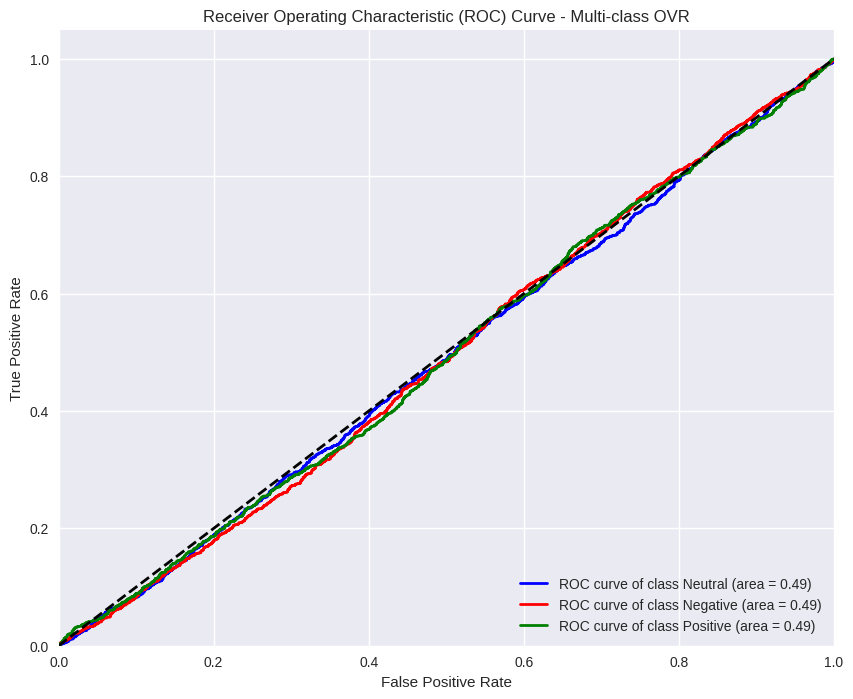

ROC AUC curve visualization complete!


In [47]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Re-evaluate the model to get probability scores for ROC AUC
full_model.eval()
full_model.to(device)

y_true_roc = []
y_scores_roc = [] # Store probabilities

print("Generating probability scores for ROC AUC...")
with torch.no_grad():
    for images, labels in tqdm(dev_loader, desc="Predicting probabilities on Dev Set"):
        images = images.to(device)
        outputs = full_model(images) # Raw logits
        probabilities = F.softmax(outputs, dim=1) # Convert logits to probabilities
        y_true_roc.extend(labels.cpu().numpy())
        y_scores_roc.extend(probabilities.cpu().numpy())

y_true_roc = np.array(y_true_roc)
y_scores_roc = np.array(y_scores_roc)

# Binarize the true labels for multi-class ROC AUC (One-vs-Rest)
n_classes = 3 # Neutral, Negative, Positive
y_true_binarized = label_binarize(y_true_roc, classes=[0, 1, 2])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_scores_roc[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_names = ['Neutral', 'Negative', 'Positive']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class OVR')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("ROC AUC curve visualization complete!")


--- Evaluating FullImageModel on Test Data ---
Generating predictions for FullImageModel on Test Set...


Predicting on Test Set: 100%|██████████| 159/159 [20:27<00:00,  7.72s/it]


FullImageModel - Classification Report on Test Data:
              precision    recall  f1-score   support

     Neutral       0.26      0.36      0.30      1298
    Negative       0.43      0.57      0.49      2163
    Positive       0.33      0.09      0.14      1606

    accuracy                           0.36      5067
   macro avg       0.34      0.34      0.31      5067
weighted avg       0.36      0.36      0.33      5067


FullImageModel - Confusion Matrix on Test Data:


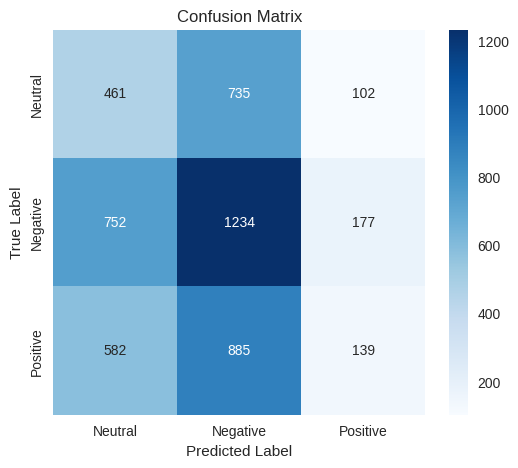


FullImageModel - ROC AUC Curve on Test Data:


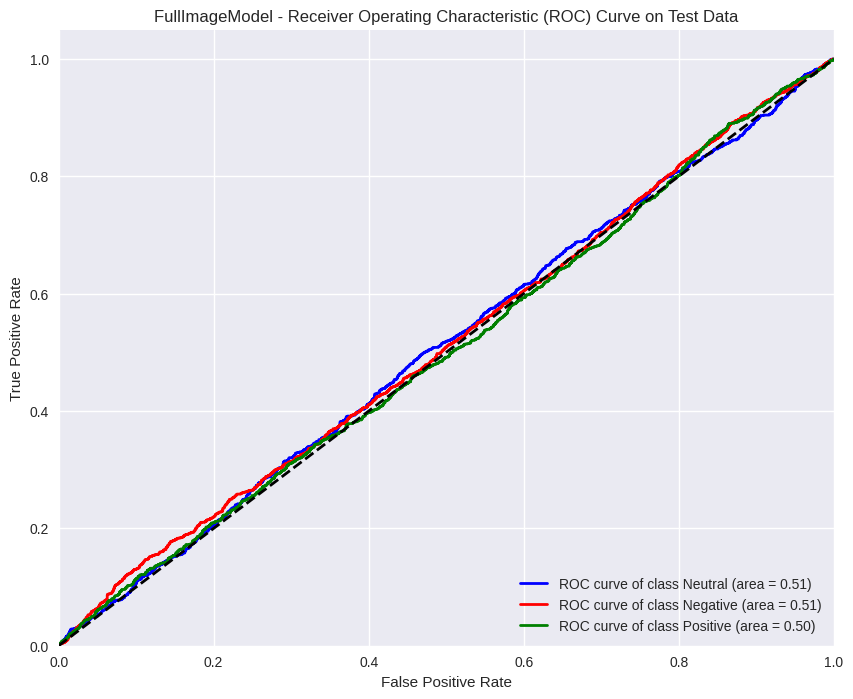

Evaluation of FullImageModel on Test Data complete!


In [48]:
# ====================== TEST SET EVALUATION ======================

test_image_dir = "/content/drive/MyDrive/datasets_s/enzh_1/test/test" # Corrected path to test images
test_sentiment = "/content/drive/MyDrive/datasets_s/enzh_1/sentiment_test.txt"

# Create test dataset and loader
test_ds = MSCTDDataset(test_image_dir, test_sentiment, test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# --- Evaluate FullImageModel on Test Data ---
print("\n--- Evaluating FullImageModel on Test Data ---")

full_model.eval()
full_model.to(device)

y_true_test = []
y_pred_test = []
y_scores_test = [] # For ROC AUC

print("Generating predictions for FullImageModel on Test Set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Predicting on Test Set"):
        images = images.to(device)
        outputs = full_model(images)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(predicted.cpu().numpy())
        y_scores_test.extend(probabilities.cpu().numpy())

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)
y_scores_test = np.array(y_scores_test)

# Classification Report (Accuracy, F1-score)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("\nFullImageModel - Classification Report on Test Data:")
print(classification_report(y_true_test, y_pred_test, target_names=['Neutral', 'Negative', 'Positive']))

# Confusion Matrix
print("\nFullImageModel - Confusion Matrix on Test Data:")
plot_confusion_matrix(y_true_test, y_pred_test)

# ROC AUC Curve
print("\nFullImageModel - ROC AUC Curve on Test Data:")
n_classes = 3
y_true_test_binarized = label_binarize(y_true_test, classes=[0, 1, 2])

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_test_binarized[:, i], y_scores_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_names = ['Neutral', 'Negative', 'Positive']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FullImageModel - Receiver Operating Characteristic (ROC) Curve on Test Data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Evaluation of FullImageModel on Test Data complete!")


# ====================== EXTRA CREDIT: MULTIMODAL TRANSFORMER ======================

In [49]:
!pip install -q transformers datasets

from transformers import ViTModel, BertModel, BertTokenizer
import torch.nn.functional as F

# ====================== UPDATED DATASET WITH TEXT ======================

In [50]:
class MSCTDMultimodalDataset(Dataset):
    def __init__(self, image_dir, sentiment_path, english_text_path, transform=None, tokenizer=None, max_len=128):
        self.image_dir = image_dir
        self.transform = transform
        self.tokenizer = tokenizer
        self.max_len = max_len

        with open(sentiment_path, 'r') as f:
            self.labels = [int(x.strip()) for x in f.readlines()]

        with open(english_text_path, 'r', encoding='utf-8') as f:
            self.texts = [line.strip() for line in f.readlines()]

        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')],
                                  key=lambda x: int(x.split('.')[0]))

        self.length = min(len(self.labels), len(self.image_files), len(self.texts))
        print(f"Loaded {self.length} multimodal samples")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Image
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Text
        text = self.texts[idx]
        if self.tokenizer:
            encoding = self.tokenizer(text, truncation=True, padding='max_length',
                                    max_length=self.max_len, return_tensors='pt')
            input_ids = encoding['input_ids'].squeeze(0)
            attention_mask = encoding['attention_mask'].squeeze(0)
        else:
            input_ids = torch.zeros(self.max_len, dtype=torch.long)
            attention_mask = torch.zeros(self.max_len, dtype=torch.long)

        label = self.labels[idx]

        return {
            'image': img,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': torch.tensor(label, dtype=torch.long)
        }

# ====================== MULTIMODAL TRANSFORMER MODEL ======================

In [51]:
class MultimodalTransformer(nn.Module):
    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()

        # Image Backbone: Vision Transformer (ViT)
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')

        # Text Backbone: BERT (supports English well)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(768 + 768, 1024),   # Concat ViT + BERT pooled outputs
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

        # Optional: Learnable weights for modality importance
        self.vit_weight = nn.Parameter(torch.tensor(0.5))
        self.text_weight = nn.Parameter(torch.tensor(0.5))

    def forward(self, images, input_ids, attention_mask):
        # Image features
        vit_outputs = self.vit(pixel_values=images)
        image_feats = vit_outputs.pooler_output  # [batch, 768]

        # Text features
        text_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = text_outputs.pooler_output   # [batch, 768]

        # Weighted Fusion (logical combination)
        fused = self.vit_weight * image_feats + self.text_weight * text_feats

        # Alternative: Simple Concat (uncomment if preferred)
        # fused = torch.cat([image_feats, text_feats], dim=1)

        output = self.fusion(fused)
        return output

# ====================== TRAINING WITH VISUALIZATION ======================

In [52]:
def train_multimodal(model, train_loader, val_loader, epochs=4):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}")

    # Plot training curve
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.title('Multimodal Transformer Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    torch.save(model.state_dict(), '/content/multimodal_transformer_final.pth')
    return model

In [53]:
# ====================== DEBUG & FIX DATASET ======================

import os

# Check all paths
base_dir = "/content/drive/MyDrive/datasets_s/enzh_1"
print("Checking directories and file counts:\n")

for split in ['train', 'dev', 'test']:
    img_dir = f"{base_dir}/{split}"
    print(f"--- {split.upper()} ---")
    print(f"Image dir exists: {os.path.exists(img_dir)}")
    if os.path.exists(img_dir):
        images = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        print(f"Number of .jpg files: {len(images)}")
        if len(images) > 0:
            print(f"Sample files: {images[:3]}")
    else:
        print("Directory NOT found!")

    # Check labels
    label_path = f"{base_dir}/sentiment_{split}.txt"
    if os.path.exists(label_path):
        with open(label_path) as f:
            labels = f.readlines()
        print(f"Number of labels: {len(labels)}")
    else:
        print(f"Label file NOT found: {label_path}")
    print("\n")

Checking directories and file counts:

--- TRAIN ---
Image dir exists: True
Number of .jpg files: 0
Number of labels: 132741


--- DEV ---
Image dir exists: True
Number of .jpg files: 0
Number of labels: 5063


--- TEST ---
Image dir exists: True
Number of .jpg files: 0
Number of labels: 5067




In [54]:
# Check where images were actually extracted
!find /content/drive/MyDrive/datasets_s/enzh_1 -name "*.jpg" | head -10

# If images are inside subfolders like "dev_images" or "images", move them:
!mkdir -p /content/drive/MyDrive/datasets_s/enzh_1/dev/images
!mkdir -p /content/drive/MyDrive/datasets_s/enzh_1/test/images

# Move if needed (adjust based on your find output)
# !mv /content/msctd/data/enzh/dev/*.jpg /content/msctd/data/enzh/dev/ 2>/dev/null || true

/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/1203.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/115.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/4487.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/2600.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/3844.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/2081.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/460.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/1097.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/4536.jpg
/content/drive/MyDrive/datasets_s/enzh_1/dev/dev/2361.jpg


In [55]:
class MSCTDDataset(Dataset):
    def __init__(self, image_dir, sentiment_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # Load labels
        with open(sentiment_path, 'r') as f:
            self.labels = [int(x.strip()) for x in f.readlines()]

        # Find all jpg files recursively (more robust)
        self.image_files = []
        for root, _, files in os.walk(image_dir):
            for f in files:
                if f.lower().endswith('.jpg'):
                    self.image_files.append(os.path.join(root, f))

        self.image_files = sorted(self.image_files,
                                  key=lambda x: int(os.path.basename(x).split('.')[0]))

        self.length = min(len(self.labels), len(self.image_files))

        print(f"✅ Dataset loaded from {image_dir}")
        print(f"   Images found : {len(self.image_files)}")
        print(f"   Labels found : {len(self.labels)}")
        print(f"   Final length : {self.length}")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Image.UnidentifiedImageError:
            # Fallback to OpenCV if PIL fails to identify image
            print(f"Warning: PIL could not process image {img_path}. Attempting with OpenCV.")
            img_cv = cv2.imread(img_path)
            if img_cv is not None:
                img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
                img = Image.fromarray(img_cv)
            else:
                raise FileNotFoundError(f"Could not load image with PIL or OpenCV: {img_path}")

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

✅ Dataset loaded from /content/drive/MyDrive/datasets_s/enzh_1/dev/dev
   Images found : 5063
   Labels found : 5063
   Final length : 5063
✅ Dataset is ready!


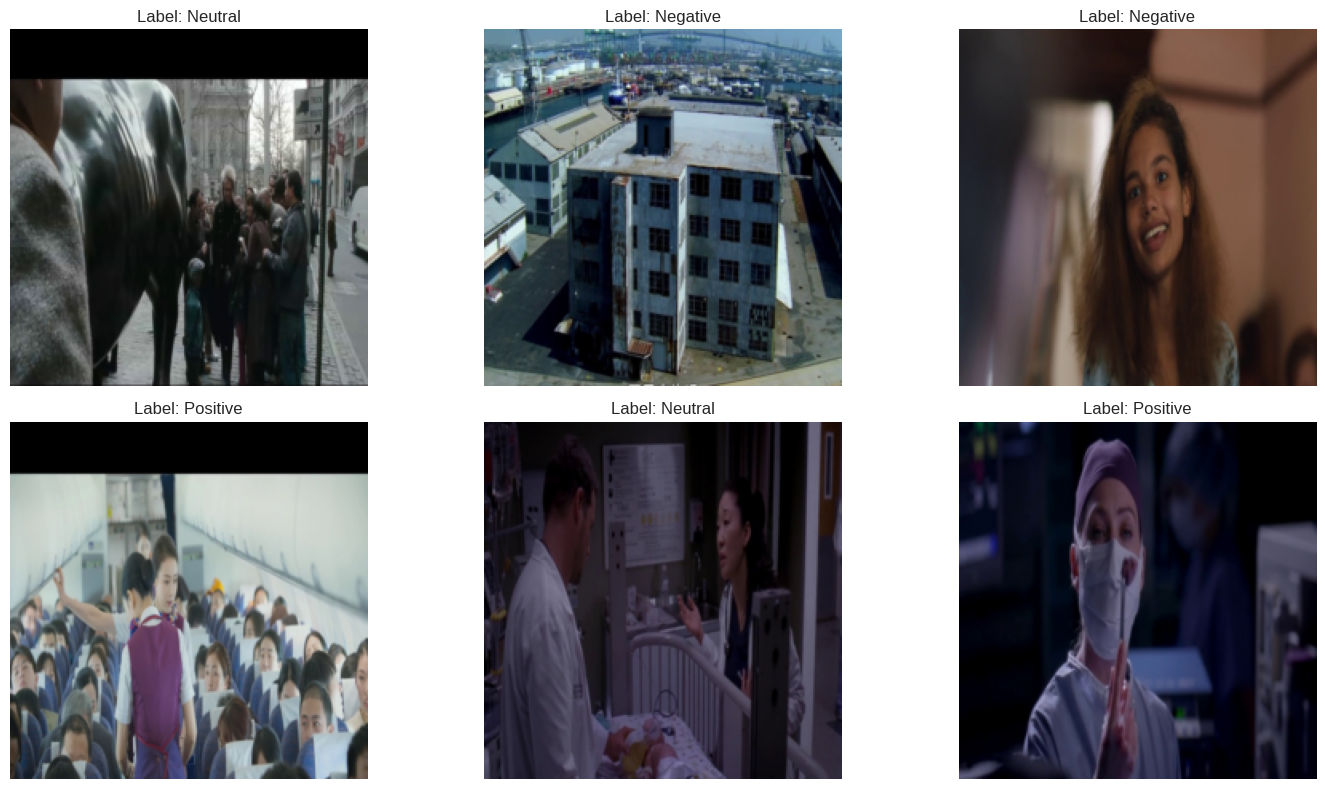

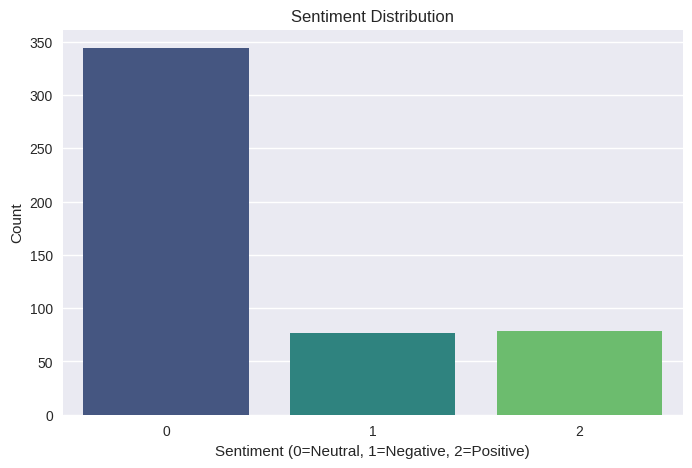

In [56]:
# ====================== RUN AFTER FIX ======================

train_image_dir = "/content/drive/MyDrive/datasets_s/enzh_1/train"
dev_image_dir   = "/content/drive/MyDrive/datasets_s/enzh_1/dev/dev"
dev_sentiment   = "/content/drive/MyDrive/datasets_s/enzh_1/sentiment_dev.txt"

dev_ds = MSCTDDataset(dev_image_dir, dev_sentiment, test_transform)

if len(dev_ds) == 0:
    print("❌ Still empty! Please check the debug output above.")
else:
    print("✅ Dataset is ready!")
    # Show samples
    show_random_samples(dev_ds, num=6)
    plot_class_distribution([dev_ds[i][1].item() for i in range(min(500, len(dev_ds)))])

Saving 30-guyangryreally.jpg to 30-guyangryreally (3).jpg


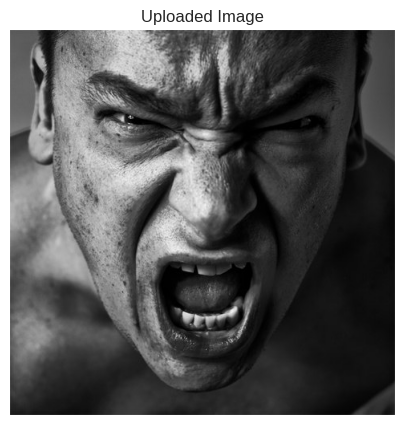

Prediction Percentages:
Neutral : 30.31%
Negative: 35.72%
Positive: 33.97%

Final Answer: Negative


In [60]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision.transforms as T

# Upload your own image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Open and display image
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image preprocessing
input_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])

# Prepare image
input_tensor = input_transform(img).unsqueeze(0).to(device)

# Use your trained full image model
full_model = full_model.to(device)
full_model.eval()

# Predict
with torch.no_grad():
    output = full_model(input_tensor)
    probabilities = F.softmax(output, dim=1)[0]

# Label order from your notebook
labels = ["Neutral", "Negative", "Positive"]

# Get final prediction
pred_index = torch.argmax(probabilities).item()
final_prediction = labels[pred_index]

# Convert probabilities to percentages
neutral_percent = probabilities[0].item() * 100
negative_percent = probabilities[1].item() * 100
positive_percent = probabilities[2].item() * 100

# Show percentage output
print("Prediction Percentages:")
print(f"Neutral : {neutral_percent:.2f}%")
print(f"Negative: {negative_percent:.2f}%")
print(f"Positive: {positive_percent:.2f}%")

print("\nFinal Answer:", final_prediction)